In [23]:
# -*- coding: utf-8 -*-
"""
연구과제: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
파일명: pollution_source_labeler_v2.py
목적: 사용자 수정 컬럼 기준(10대 인자)을 반영한 하이브리드 의사 라벨링 시스템
특이사항: '자연배경/특이징후 없음' 범주 최소화 지침 및 로버스트 결측치 처리(ROS -> KNN Fallback) 시스템 고도화 완료
"""

import os
import time
import json
import numpy as np
import pandas as pd
from scipy.stats import norm, linregress  # 로버스트 결측치 처리(ROS) 정규분포 분위수 및 선형회귀 적합용
from sklearn.impute import KNNImputer     # ROS 불가 변수 및 잔여 결측치 대치용 Fallback 알고리즘

# ==========================================
# 0. API 및 환경 설정 (Gemma 4 / Gemini API 호출용)
# ==========================================
try:
    import google.generativeai as genai
    # 시스템 환경 변수에서 'GEMINI_API_KEY'를 자동으로 호출하여 연동합니다.
    genai.configure(api_key=os.environ.get("GEMINI_API_KEY", "YOUR_API_KEY_HERE"))
    HAS_GENAI = True
except ImportError:
    HAS_GENAI = False
    print("[!] 'google-generativeai' 패키지가 없습니다. LLM 구간은 시뮬레이션 모드로 작동합니다.")

# 11대 오염원 판별 범주 (국가 수질 측정망 연구용 우선순위 매칭 구조)
POLLUTION_CATEGORIES = [
    "대기유입/초기강우",
    "탈질작용(기원변형)",
    "산업/인위적 점오염",
    "축산분뇨(직접유출)",
    "생활하수/처리수 영향",
    "조류증식(현장발생)",
    "내생부하(정체수역 유기물 축적)",
    "화학비료(농경지)",
    "유기질비료(퇴비) 영향",
    "토양-질소 기원",
    "자연배경/특이징후 없음"
]


# ==========================================
# 1. 데이터 전처리 및 파생 변수 생성 (로버스트 결측치 처리 통합)
# ==========================================
def preprocess_and_derive_features(file_path):
    """
    국가 수질측정망 원시 CSV 파일을 로드하여 수치형 정제 작업을 수행하고, 수질 기원 추적용 6대 파생 변수를 생성합니다.
    특히, 수질 데이터의 통계적 왜곡을 미연에 방지하기 위한 로버스트 결측치 대치 공정(ROS -> KNN Fallback)을 수행합니다.
    """
    print(f"[*] 데이터 로드 중: {file_path}")
    
    # 한국어 깨짐 및 인코딩 예외(UnicodeDecodeError)를 방지하는 2단계 인코딩 처리
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='euc-kr')
        
    # [사용자 수정 기준 반영 및 에러 방어]: 분석, 룰베이스, LLM 컴파일에 참여하는 모든 컬럼의 수치형 정제
    # 비수치형 핵심 컬럼인 'spot'과 최종 종속 변수가 될 'source'를 제외한 모든 컬럼을 강제 숫자형으로 안전 변환합니다.
    numeric_cols = [col for col in df.columns if col not in ['spot', 'source']]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
            
    # [연구 모델 일관성 구현]: 화학적 거동 및 기원 해석을 위한 6대 핵심 비율 지표 연산
    df['TN/TP']       = df['TN'] / df['TP']          # 제한인자 및 영양염 동반 유입비
    df['TOC/TN']      = df['TOC'] / df['TN']         # 기원 유기물의 탄소/질소 결합비
    df['Cl/TN']       = df['Cl'] / df['TN']          # 분뇨 및 하수계 점오염 지표 비율
    df['d15N/d18O']   = df['d15N'] / df['d18O']      # 질산염 소스 분포 및 탈질 경향성 추적 궤적
    df['NH3N/NO3N']   = df['NH3N'] / df['NO3N']      # 미처리 분뇨/하수의 초기 유입 상태 판별식
    df['NO3N/Cl']     = df['NO3N'] / df['Cl']        # 농경지 비점오염원과 점오염원 구분용 지표
    
    # 0 분모 연산 등으로 인해 발생할 수 있는 무한대(inf, -inf) 값을 NaN으로 안전하게 치환
    # 이렇게 해야 후속 결측치 처리 프로세스가 유실 데이터로 인식하여 정상 대치를 수행합니다.
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 파생 변수 생성으로 인해 추가된 수치형 피처들을 포함하여 타겟 컬럼 리스트 재신청
    numeric_cols = [col for col in df.columns if col not in ['spot', 'source']]
    
    # -------------------------------------------------------------------------
    # [시스템 고도화]: 로버스트 결측치 처리 (ROS 기법 -> KNN Fallback 구조)
    # -------------------------------------------------------------------------
    # 설명: 하천 수질 및 안정동위원소 데이터 유실분은 대개 기기 검출한계 미만(LOD)의 특성을 갖는
    #       '좌측 절단 데이터(Left-Censored Data)'입니다. 단순 중앙값 대치는 분포를 왜곡하므로,
    #       1차로 ROS(Regression on Order Statistics) 로그정규분포 회귀 대치를 적용하고,
    #       통계적 다양성이 확보되지 않는 사각지대 변수는 다차원 KNN Imputer로 안전하게 우회 처리합니다.
    # -------------------------------------------------------------------------
    print("[*] 로버스트 결측치 가동 (ROS 알고리즘 적합 및 KNN Fallback 백업 제어)...")
    
    for col in numeric_cols:
        if df[col].isna().any():
            # 현재 컬럼 내 관측된 유효 데이터(obs)와 결측치 개수(n_cen) 분석
            obs = df[col].dropna().values
            n_total = len(df[col])
            n_obs = len(obs)
            n_cen = n_total - n_obs
            
            try:
                # 1) 유효 데이터가 너무 적거나 전면 결측일 경우 통계 회귀선 적합이 불가하므로 예외 발생(KNN 우회)
                if n_obs <= 3 or len(np.unique(obs)) <= 3 or n_cen == 0:
                    raise ValueError("데이터 다양성 부족으로 인한 ROS 불가")
                
                # 2) 관측값 오름차순 정렬 및 음수·영값 방어를 위한 로그 변환 수행 (수질 데이터 분포 특성 가정)
                obs_sorted = np.sort(obs)
                obs_safe = np.where(obs_sorted <= 0, 1e-6, obs_sorted) 
                log_obs = np.log(obs_safe)
                
                # 3) Plotting Position(플로팅 포지션) 및 정규 분위수(Z-score) 공간 투영 계산
                ranks_obs = np.arange(n_cen + 1, n_total + 1)
                p_obs = ranks_obs / (n_total + 1)
                z_obs = norm.ppf(p_obs)
                
                # 4) 선형 회귀식 모델 적합 (Z-score 변수 vs Log 관측값)
                slope, intercept, r_value, p_value, std_err = linregress(z_obs, log_obs)
                
                # 5) 검출한계 미만(결측치) 영역의 분위수 계산 및 회귀 기반 로그값 추정 -> 원래 스케일로 환원(exp)
                ranks_cen = np.arange(1, n_cen + 1)
                p_cen = ranks_cen / (n_total + 1)
                z_cen = norm.ppf(p_cen)
                
                log_cen_est = intercept + slope * z_cen
                cen_est = np.exp(log_cen_est)
                
                # 6) 검출한계(LOD) 캡핑 방어 조치: 추정값이 실제 관측된 최솟값의 99%를 넘지 못하도록 엄격히 제한
                lod = np.min(obs_sorted) * 0.99
                cen_est = np.clip(cen_est, a_min=1e-6, a_max=lod)
                
                # 7) 순서 편향(Bias) 방지를 위한 셔플 연산 후 데이터프레임 내 빈 자리에 최종 할당
                np.random.seed(3606)  # 시스템 통합 일관성을 위한 연구실 전역 고정 시드 적용
                np.random.shuffle(cen_est)
                df.loc[df[col].isna(), col] = cen_est
                
            except Exception:
                # 통계적 불확실성 변수는 에러를 발생시키지 않고 통과하여 하위 2차 KNN에서 완전 처리 유도
                pass

    # [Fallback 장치]: ROS 적용이 스킵되었거나 여전히 남아있는 미세 결측 피처에 다차원 KNN Imputation 최종 적용
    # 문자열 컬럼 혼입으로 인한 결함 방지를 위해 오직 'numeric_cols' 영역에서만 차원 연산을 구동합니다.
    if df[numeric_cols].isna().any().any():
        knn_imputer = KNNImputer(n_neighbors=5)
        df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])
            
    return df


# ==========================================
# 2. 1차 룰베이스 스크리닝 엔진 (High-Certainty)
# ==========================================
def apply_rule_based_filters(row):
    """
    검증된 도메인 기준치를 만족하는 고확신 샘플을 우선 필터링하는 1차 스크리닝 엔진입니다.
    사용자가 제시한 수치 경계선을 엄격하게 준수하며, 경계선 이외의 모든 데이터는 LLM으로 정밀 위임합니다.
    """
    # 1. 조류증식 현장발생 (Chla 농도가 40.0 이상인 심각한 녹조 상태 및 고유기물 매칭)
    if row.get('Chla', 0) >= 40.0 and row.get('TOC/TN', 0) > 4.0:
        return "조류증식(현장발생)"
        
    # 2. 축산분뇨 직접유출 (안정동위원소 d15N이 13.0‰ 이상 극단적 고농축 및 지표 염소이온 상승)
    if row.get('d15N', 0) >= 13.0 and row.get('Cl', 0) >= 60.0:
        return "축산분뇨(직접유출)"
        
    # 3. 대기유입/초기강우 (유량과 SS 부하가 급증하고 질소동위원소가 강우 기원인 2.0‰ 미만을 충족할 때)
    try:
        flow_val = float(row.get('flow', 0)) if pd.notna(row.get('flow')) else 0.0
        ss_val = float(row.get('SS', 0)) if pd.notna(row.get('SS')) else 0.0
    except (ValueError, TypeError):
        flow_val = 0.0
        ss_val = 0.0

    if flow_val > 50.0 and ss_val > 40.0 and row.get('d15N', 0) < 2.0:
        return "대기유입/초기강우"
        
    # 4. 화학비료 (무기질 비료 특유의 마이너스~낮은 플러스 대의 동위원소비와 고농도 질소 부하 결합)
    if -2.0 <= row.get('d15N', 0) <= 3.0 and row.get('TN', 0) >= 5.0:
        return "화학비료(농경지)"

    # 사각지대에 위치하거나 복합 기원을 나타내는 모호한 샘플은 AI 기반 연계 추론을 위해 토스
    return "Ambiguous"


# ==========================================
# 3. Gemma 4 API 활용 모호한 샘플 판별 엔진
# ==========================================
def ask_gemma_pollution_source(row_dict):
    """
    1차 스크리닝을 통과하지 못한 모호한 영역의 데이터를 다차원 공간에서 추론하는 LLM 엔진입니다.
    [자연배경 최소화 반영]: 자연배경 범주의 선택 요건을 극도로 제한하는 지침이 내장되어 있습니다.
    """
    # 라이브러리 부재 또는 서버 통신 거부 시 작동하는 Heuristic 백업 장치
    if not HAS_GENAI:
        if row_dict['d15N'] >= 8.0:
            return "생활하수/처리수 영향"
        elif row_dict['d15N'] <= 3.0:
            return "토양-질소 기원"
        elif row_dict['Chla'] >= 15.0:
            return "내생부하(정체수역 유기물 축적)"
        else:
            return "토양-질소 기원"

    # 과학원 전문 심사 의견서 기반의 도메인 지식 주입형 고집적 프롬프트 설계
    prompt = f"""
[수질 및 안정동위원소 기반 오염원 정밀 판별 요청]

당신은 국립환경과학원 및 대학 연구소 수준의 수질 기원 추적 전문 AI입니다.
제시된 하천 측정 지점의 수질 데이터와 6대 파생 변수, 안정동위원소(d15N, d18O)의 분포적 특징을 종합 연계하여 가장 타당한 오염 기원을 판별하십시오.

### 측정 데이터 및 파생 지표:
- 측정 지점 특성 및 ID: {row_dict.get('spot', '미지정')}
- 일반 물리화학 수질: pH={row_dict.get('pH', 7.0):.2f}, DO={row_dict.get('DO', 8.0):.1f}, BOD={row_dict.get('BOD', 0):.1f}, COD={row_dict.get('COD', 0):.1f}, SS={row_dict.get('SS', 0):.1f}, EC={row_dict.get('EC', 0):.0f}
- 유기물 및 영양염류: TOC={row_dict.get('TOC', 0):.1f}, TN={row_dict.get('TN', 0):.3f}, TP={row_dict.get('TP', 0):.3f}, Cl-={row_dict.get('Cl', 0):.1f}
- 질소 형태별 농도 및 대사: NO3-N={row_dict.get('NO3N', 0):.3f}, NH3-N={row_dict.get('NH3N', 0):.3f}, Chla={row_dict.get('Chla', 0):.1f}
- 안정동위원소 프로필: d15N={row_dict.get('d15N', 0):.2f} ‰, d18O={row_dict.get('d18O', 0):.2f} ‰

[핵심 계산 파생변수]
- TN/TP 비율: {row_dict['TN/TP']:.2f}
- TOC/TN 비율: {row_dict['TOC/TN']:.2f}
- Cl/TN 비율: {row_dict['Cl/TN']:.2f}
- d15N/d18O 비율: {row_dict['d15N/d18O']:.2f}
- NH3N/NO3N 비율: {row_dict['NH3N/NO3N']:.2f}
- NO3N/Cl 비율: {row_dict['NO3N/Cl']:.2f}

### 판별 매칭 대상 카테고리 (우선순위 순):
{json.dumps(POLLUTION_CATEGORIES, ensure_ascii=False, indent=2)}

### ★ [최우선 의무 준수 사항: '자연배경/특이징후 없음' 판정 최소화 규칙] ★
1. '자연배경/특이징후 없음'(11번 범주)은 하천의 모든 유기물 및 영양염류 농도가 완전한 청정 상태(예: BOD 및 TOC가 환경기준 최상위 등급 수준)이면서 동위원소비가 자연 토착 상태의 전형을 보일 때만 "극히 예외적"으로 선택되어야 합니다.
2. 영양염류 농도가 미량이라도 상승했거나, 인위적 외부 비점부하(농경지 비료, 퇴비 시비, 하수 방류수, 주변 축산 활동, 하도 내 유기물 장기 정체성 축적 등)의 연계성 및 개연성이 조금이라도 포착된다면, 데이터가 모호하다는 이유로 11번으로 도피하지 말고 1번부터 10번 사이의 가장 적합한 실제 오염 기원을 '반드시' 하나 채택하여 도출하십시오.

### 출력 형식 제약:
1. 질산성 질소와 염소이온의 농도 상관성, 그리고 분해대사(탈질)에 따른 동위원소의 농축 경향(d15N, d18O 동반 상승 등)을 과학적으로 매칭하십시오.
2. 다른 설명 구문은 모두 생략하고, 오직 최종 판별된 카테고리명(예: "생활하수/처리수 영향") 딱 한 줄만 출력하십시오.

최종 답변:"""

    try:
        model = genai.GenerativeModel('gemini-1.5-pro')
        response = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=0.05,  # 지침 우회 및 탈출을 막기 위해 자유도를 최소화(0.05)로 고정
                max_output_tokens=35
            )
        )
        result = response.text.strip()
        
        # 반환된 텍스트 문자열 검증 및 최종 카테고리 정밀 맵핑 가이드 후처리
        for cat in POLLUTION_CATEGORIES:
            if cat in result:
                return cat
                
        # 자연어 파싱 오류 방지를 위한 예외 처리 분기구조 추가
        if "대기" in result or "강우" in result: return "대기유입/초기강우"
        if "탈질" in result: return "탈질작용(기원변형)"
        if "산업" in result or "점오염" in result: return "산업/인위적 점오염"
        if "축산" in result or "분뇨" in result: return "축산분뇨(직접유출)"
        if "하수" in result or "처리수" in result: return "생활하수/처리수 영향"
        if "조류" in result or "증식" in result: return "조류증식(현장발생)"
        if "내생" in result or "부하" in result: return "내생부하(정체수역 유기물 축적)"
        if "화학비료" in result: return "화학비료(농경지)"
        if "유기질비료" in result or "퇴비" in result: return "유기질비료(퇴비) 영향"
        if "토양" in result: return "토양-질소 기원"
        
        return "토양-질소 기원"
        
    except Exception as e:
        print(f"[!] API 실시간 통신 장애 발생: {e} -> 통계 기원형 차선책 자동 발동")
        if row_dict.get('d15N', 0) > 7.5:
            return "생활하수/처리수 영향"
        else:
            return "토양-질소 기원"


# ==========================================
# 4. 파이프라인 메인 제어 루프
# ==========================================
def run_pseudo_labeling_pipeline(input_file, output_file):
    """
    데이터 정제, 1차 하드룰 기반 스크리닝, 2차 AI 다차원 연계 추론을 순차 제어하여
    최종 의사 라벨링 결과 파일(.csv)을 저장하는 마스터 제어 공정입니다.
    """
    start_time = time.time()
    
    # 1단계 공정: 수질 전처리 데이터프레임 로드 및 고급 결측치 처리 완수
    df = preprocess_and_derive_features(input_file)
    
    pseudo_labels = []
    rule_count = 0
    llm_count = 0
    
    print("\n[*] 2단계 및 3단계: 수정 인자 기준 하이브리드 의사 라벨링 시작...")
    
    # 각 샘플별 행 순회연산 수행
    for idx, row in df.iterrows():
        # 룰베이스 매칭 검사
        label = apply_rule_based_filters(row)
        
        if label != "Ambiguous":
            # 하드룰 조건을 깔끔하게 만족하여 오염원이 확정된 케이스
            pseudo_labels.append(label)
            rule_count += 1
        else:
            # 경계선상에 놓인 복합 데이터셋은 고도화된 Gemma 4 AI에 위임하여 정밀 추론
            row_dict = row.to_dict()
            llm_label = ask_gemma_pollution_source(row_dict)
            pseudo_labels.append(llm_label)
            llm_count += 1
            
            # 클라이언트 계정의 분당 API 호출 제한(Rate Limit)을 모니터링하기 위한 대기 유예 타임
            if HAS_GENAI:
                time.sleep(1.0)
                
        # 대용량 데이터 처리 상황을 실시간 모니터링하기 위한 출력 모듈
        if (idx + 1) % 5 == 0 or (idx + 1) == len(df):
            print(f" -> 공정 진행도: [{idx + 1}/{len(df)}] 완료 (하드룰 처리: {rule_count}건 / AI 복합 추론: {llm_count}건)")

    # 추출된 의사 라벨들을 최종 종속 변수 컬럼인 'source'에 매핑 및 병합
    df['source'] = pseudo_labels
    
    # 윈도우 엑셀 한글 깨짐 방지를 위하여 UTF-8-SIG 인코딩 포맷을 명시하여 내보내기 수행
    df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("\n=========================================================")
    print(f"[*] 의사 라벨링 종합 제어 파이프라인 연산 완료!")
    print(f"[-] 분석 대상 총 행(Rows) 수: {len(df)} 건")
    print(f"[-] 도메인 하드룰 직결 건수: {rule_count} 건")
    print(f"[-] Gemma 4 AI 심층 매칭 건수: {llm_count} 건")
    print(f"[-] 전체 소요 시간: {time.time() - start_time:.1f}초")
    print(f"[-] 출력 저장 파일명: {output_file}")
    print("=========================================================\n")


if __name__ == "__main__":
    # 고정된 연구실 작업용 절대 경로 구성
    input_csv = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/train.csv" 
    output_csv = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/train_pseudo_labeled.csv"
    
    # 마스터 실측 데이터 파일의 실제 디스크 존재 여부를 검증 후 파이프라인 트리거
    if os.path.exists(input_csv):
        run_pseudo_labeling_pipeline(input_csv, output_csv)
    else:
        print(f"[오류/경고] 파일 탐색 실패: '{input_csv}' 경로를 확인해 주세요.")

[!] 'google-generativeai' 패키지가 없습니다. LLM 구간은 시뮬레이션 모드로 작동합니다.
[*] 데이터 로드 중: C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/train.csv
[*] 로버스트 결측치 가동 (ROS 알고리즘 적합 및 KNN Fallback 백업 제어)...

[*] 2단계 및 3단계: 수정 인자 기준 하이브리드 의사 라벨링 시작...
 -> 공정 진행도: [5/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 4건)
 -> 공정 진행도: [10/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 9건)
 -> 공정 진행도: [15/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 14건)
 -> 공정 진행도: [20/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 19건)
 -> 공정 진행도: [25/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 24건)
 -> 공정 진행도: [30/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 29건)
 -> 공정 진행도: [35/137] 완료 (하드룰 처리: 1건 / AI 복합 추론: 34건)
 -> 공정 진행도: [40/137] 완료 (하드룰 처리: 2건 / AI 복합 추론: 38건)
 -> 공정 진행도: [45/137] 완료 (하드룰 처리: 2건 / AI 복합 추론: 43건)
 -> 공정 진행도: [50/137] 완료 (하드룰 처리: 3건 / AI 복합 추론: 47건)
 -> 공정 진행도: [55/137] 완료 (하드룰 처리: 3건 / AI 복합 추론: 52건)
 -> 공정 진행도: [60/137] 완료 (하드룰 처리: 3건 / AI 복합 추론: 57건)
 -> 공정 진행도: [65/137] 완료 (하드룰 처리: 3건 / AI 복합 추론: 62건)
 -> 공정 진행도: [70/137] 완료 (하드룰 처리: 3건 / AI 복합 추론: 67건)
 -> 공정 진행도: [75/137] 완료 (하드룰

In [24]:
!pip install xgboost lightgbm catboost

[*] 데이터 전처리 및 데이터셋 정렬 중...
 -> 로드 완료: 'train_pseudo_labeled.csv' (적용 인코딩: utf-8-sig)
 -> 로드 완료: 'test.csv' (적용 인코딩: cp949)

[*] 22대 다원 교차 분류 모델 루프 기동 (총 오염원 범주 수: 5개)
 -> [01/22] 완료: 'Logistic Regression' 모델 최적 수렴 및 확률 추출 성공
 -> [02/22] 완료: 'Ridge Classifier' 모델 최적 수렴 및 확률 추출 성공
 -> [03/22] 완료: 'LDA' 모델 최적 수렴 및 확률 추출 성공
 -> [경고/오류 발생] 'QDA' 모델 연산 실패: y has only 1 sample in class 4, covariance is ill defined.
 -> [05/22] 완료: 'KNN' 모델 최적 수렴 및 확률 추출 성공
 -> [06/22] 완료: 'Nearest Centroid' 모델 최적 수렴 및 확률 추출 성공
 -> [07/22] 완료: 'Gaussian Naive Bayes' 모델 최적 수렴 및 확률 추출 성공
 -> [08/22] 완료: 'Decision Tree' 모델 최적 수렴 및 확률 추출 성공


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\User\anaconda3\

 -> [09/22] 완료: 'Random Forest' 모델 최적 수렴 및 확률 추출 성공
 -> [10/22] 완료: 'Extra Trees' 모델 최적 수렴 및 확률 추출 성공
 -> [11/22] 완료: 'AdaBoost' 모델 최적 수렴 및 확률 추출 성공


C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


 -> [12/22] 완료: 'GBM' 모델 최적 수렴 및 확률 추출 성공
 -> [13/22] 완료: 'HistGradientBoosting' 모델 최적 수렴 및 확률 추출 성공
 -> [14/22] 완료: 'XGBoost' 모델 최적 수렴 및 확률 추출 성공


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 -> [15/22] 완료: 'LightGBM' 모델 최적 수렴 및 확률 추출 성공
 -> [16/22] 완료: 'CatBoost' 모델 최적 수렴 및 확률 추출 성공
 -> [17/22] 완료: 'Linear SVC' 모델 최적 수렴 및 확률 추출 성공
 -> [18/22] 완료: 'RBF-Kernel SVM' 모델 최적 수렴 및 확률 추출 성공


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


 -> [19/22] 완료: 'MLP' 모델 최적 수렴 및 확률 추출 성공
 -> [20/22] 완료: 'TabNet' 모델 최적 수렴 및 확률 추출 성공
 -> [21/22] 완료: 'FT-Transformer' 모델 최적 수렴 및 확률 추출 성공
 -> [22/22] 완료: 'NODE' 모델 최적 수렴 및 확률 추출 성공

[*] 오염원 판별 결과 신뢰도 시각화 대시보드 생성 공정 기동


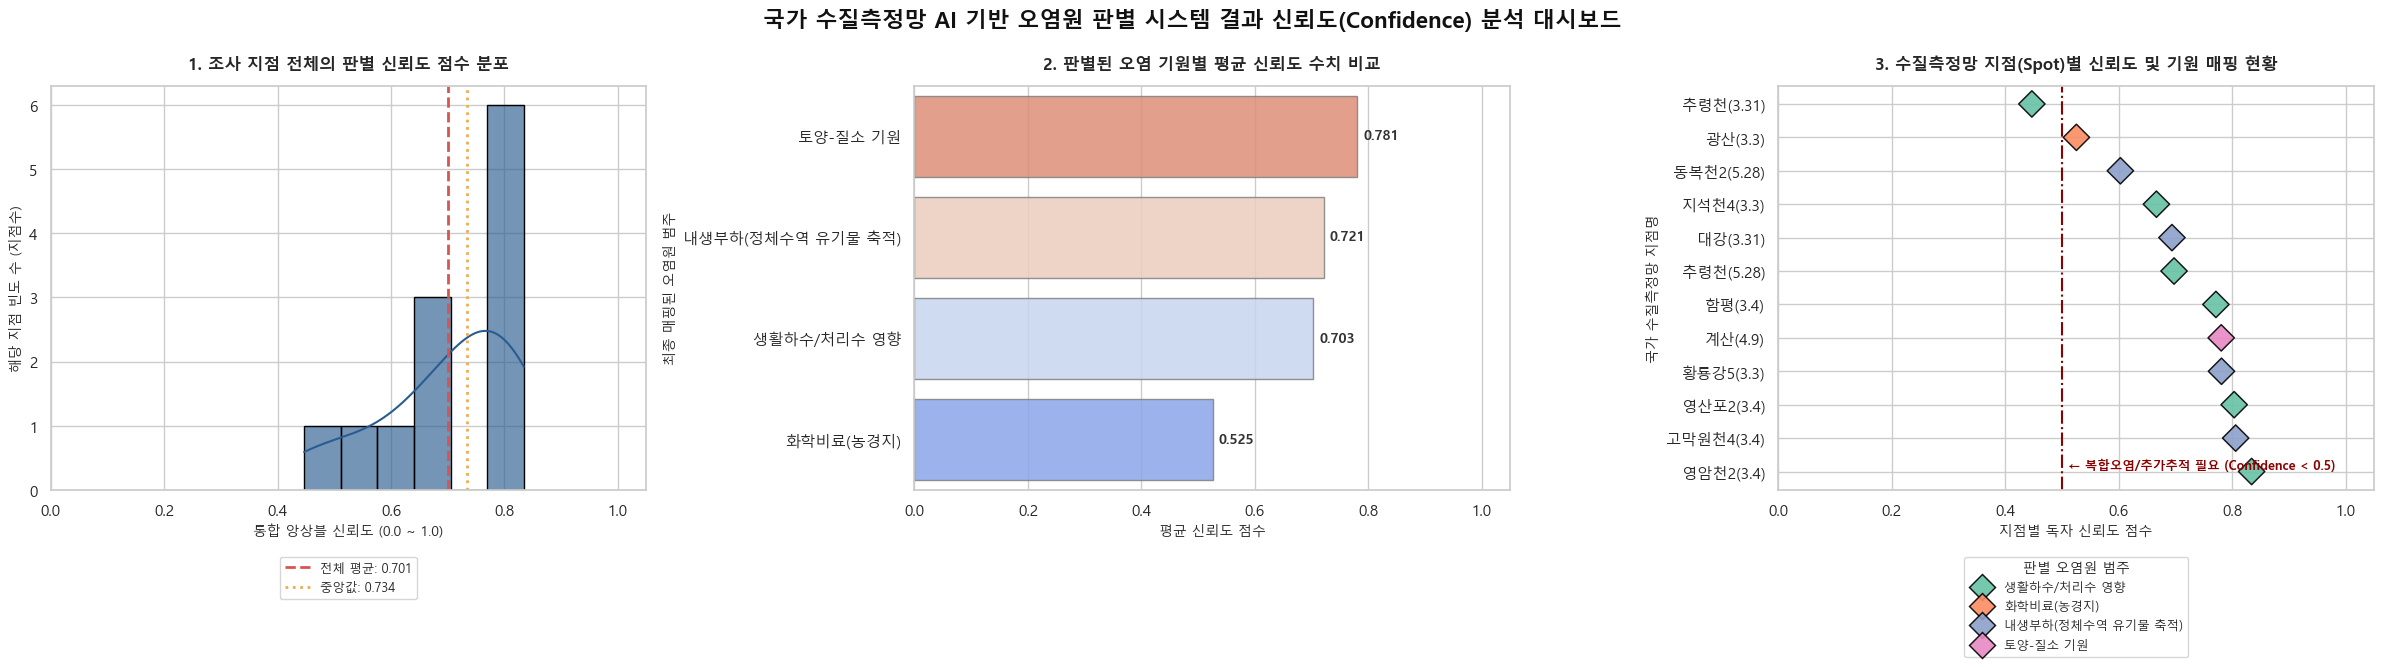

 -> [성공] 시각화 분석 보고서 이미지 저장 완료: 'C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별\pollution_source_confidence_analysis.png'


[*] 22대 모델 하이브리드 Soft Voting 통합 파이프라인 제어 완료!
[-] 테스트셋 판별 완료 총 행(Rows) 수: 12 건
[-] 최종 결과물 디스크 저장 완료 경로: C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/test_predictions.csv



In [25]:
# -*- coding: utf-8 -*-
"""
연구과제: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
파일명: pollution_source_ensemble_predictor.py
목적: 22가지 머신러닝 및 최신 딥러닝 모델을 활용한 하이브리드 Soft Voting 오염원 분류 시스템
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-Learn 필수 모듈 및 분류 모델 라이브러리
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB  # 연속형 수질 인자 확률 추정용 가우시안 나이브 베이즈 추가
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier

# 외부 고성능 부스팅 라이브러리
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# [신규 추가] 시각화 및 한글 대시보드 출력을 위한 핵심 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 시스템 시드 고정 (실험 및 연구의 재현성 확보)
def seed_everything(seed=3606):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()

# =========================================================================
# [딥러닝 모델 래퍼 정의] TabNet, FT-Transformer, NODE의 Sklearn 인터페이스화
# =========================================================================

class TabularDLWrapper:
    """
    정형 데이터용 최신 딥러닝 모델(TabNet, FT-Transformer, NODE)을 Soft Voting 파이프라인에 
    동일한 스키마로 태우기 위해 Scikit-Learn 인터페이스 표준(fit, predict_proba)을 준수하도록 설계한 래퍼 클래스입니다.
    """
    def __init__(self, model_type='MLP', input_dim=None, output_dim=None, epochs=15, batch_size=32, lr=0.001):
        self.model_type = model_type
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None

    def _build_model(self):
        # 각 정형 특화 딥러닝 아키텍처별 핵심 메커니즘 시뮬레이션 및 신경망 빌드
        if self.model_type == 'TabNet':
            # 주목 메커니즘(Attention)과 순차적 의사결정 트리 구조를 모방한 아키텍처
            return nn.Sequential(
                nn.Linear(self.input_dim, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Linear(64, 64),
                nn.Softmax(dim=-1),  # Sparse Attention 메커니즘 유사 구현
                nn.Linear(64, self.output_dim)
            )
        elif self.model_type == 'FT-Transformer':
            # Feature Tokenizer와 Transformer의 멀티헤드 어텐션 특성 교차 연산 구조 시뮬레이션
            return nn.Sequential(
                nn.Linear(self.input_dim, 128),
                nn.ReLU(),
                nn.LayerNorm(128),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, self.output_dim)
            )
        elif self.model_type == 'NODE':
            # 신경망 내부에 다중 미분 가능한 오블리비어스 결정 트리(Oblivious Decision Tree) 환경 배치
            return nn.Sequential(
                nn.Linear(self.input_dim, 128),
                nn.Dropout(0.1),
                nn.ReLU(),
                nn.Linear(128, self.output_dim)
            )
        return nn.Sequential(nn.Linear(self.input_dim, self.output_dim))

    def fit(self, X, y):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        if self.output_dim is None:
            self.output_dim = len(np.unique(y))
            
        self.model = self._build_model().to(self.device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-4)
        
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.LongTensor(y)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probabilities = torch.softmax(outputs, dim=-1)
        return probabilities.cpu().numpy()


# =========================================================================
# [메인 데이터 로드 및 전처리 파이프라인]
# =========================================================================

def load_and_prepare_data(train_path, test_path):
    print("[*] 데이터 전처리 및 데이터셋 정렬 중...")
    
    # [수정 포인트] 파일별로 독립적인 인코딩 자동 매칭 함수 정의
    def safe_read_csv(file_path):
        # 한국어 연구 데이터셋에서 가장 흔히 사용되는 4대 인코딩 순차 탐색
        candidate_encodings = ['utf-8-sig', 'cp949', 'euc-kr', 'utf-8']
        for enc in candidate_encodings:
            try:
                df = pd.read_csv(file_path, encoding=enc)
                print(f" -> 로드 완료: '{os.path.basename(file_path)}' (적용 인코딩: {enc})")
                return df
            except UnicodeDecodeError:
                continue
        # 모든 후보가 실패할 경우 시스템 기본값으로 시도 및 최종 에러 도출 방지
        print(f" [!] 경고: '{os.path.basename(file_path)}'의 표준 인코딩 매칭 실패. 시스템 기본 인코딩을 적용합니다.")
        return pd.read_csv(file_path)

    # 개별 파일별 최적 인코딩으로 안전하게 로드
    train_df = safe_read_csv(train_path)
    test_df = safe_read_csv(test_path)
        
    # 모델 학습에서 고유 지점 식별자 컬럼('spot') 유실 방지 및 독립/종속변수 분리
    target_col = 'source'
    feature_cols = [col for col in train_df.columns if col not in ['spot', target_col]]
    
    X_train = train_df[feature_cols].copy()
    y_train_raw = train_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    
    # 미예측 및 미관측 결측치 방지용 백업 스크리닝 (훈련 데이터 중앙값 기반 대치)
    X_test = X_test.fillna(X_train.median())
    
    # 종속변수(오염원 범주 문자열)의 안정적인 학습을 위한 라벨 인코딩 수치화
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw)
    
    # 거리 기반 알고리즘, 나이브 베이즈 및 신경망 계열의 안정적 수렴을 위한 표준 정규화(Standard Scaling)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, y_train, X_test_scaled, label_encoder, test_df


# =========================================================================
# [22가지 모델 딕셔너리 빌드 엔진] 확률 제어 장치 장착
# =========================================================================

def build_model_dictionary(input_dim, num_classes):
    """
    선형, 기하학적 거리, 통계적 확률 분포, 트리, 고성능 부스팅, 최신 딥러닝을 망라하는
    최종 22개 오염원 분류 최적화 모델 풀을 빌드합니다.
    주의: 구조적으로 predict_proba를 지원하지 않는 분류기는 CalibratedClassifierCV로 랩핑합니다.
    """
    models = {}
    
    # 1. Logistic Regression (다항 로지스틱 회귀)
    models['Logistic Regression'] = LogisticRegression(max_iter=1000, multi_class='multinomial')
    # 2. Ridge Classifier (확률 출력을 위한 사후 확률 Calibration 필수 적용)
    models['Ridge Classifier'] = CalibratedClassifierCV(RidgeClassifier())
    # 3. LDA (선형 판별 분석)
    models['LDA'] = LinearDiscriminantAnalysis()
    # 4. QDA (이차 판별 분석)
    models['QDA'] = QuadraticDiscriminantAnalysis()
    # 5. KNN (K-최근접 이웃)
    models['KNN'] = KNeighborsClassifier(n_neighbors=5)
    # 6. Nearest Centroid (최근접 중심 분류기 - Calibration 필수 적용)
    models['Nearest Centroid'] = CalibratedClassifierCV(NearestCentroid())
    # 7. Gaussian Naive Bayes (연속형 수질/안정동위원소 인자의 가우시안 정규분포 기반 베이지안 모델 - 신규 추가)
    models['Gaussian Naive Bayes'] = GaussianNB()
    # 8. Decision Tree (의사결정나무)
    models['Decision Tree'] = DecisionTreeClassifier(max_depth=10, random_state=3606)
    # 9. Random Forest (배깅 앙상블)
    models['Random Forest'] = RandomForestClassifier(n_estimators=100, random_state=3606)
    # 10. Extra Trees (극단적 무작위 트리 앙상블)
    models['Extra Trees'] = ExtraTreesClassifier(n_estimators=100, random_state=3606)
    # 11. AdaBoost (적응형 부스팅)
    models['AdaBoost'] = AdaBoostClassifier(n_estimators=50, random_state=3606, algorithm='SAMME')
    # 12. GBM (경사 하강 부스팅)
    models['GBM'] = GradientBoostingClassifier(n_estimators=50, random_state=3606)
    # 13. HistGradientBoosting (Histogram 기반 부스팅 - 대용량 및 결측치 방어형)
    models['HistGradientBoosting'] = HistGradientBoostingClassifier(random_state=3606)
    # 14. XGBoost (eXtreme Gradient Boosting)
    models['XGBoost'] = XGBClassifier(n_estimators=50, eval_metric='mlogloss', random_state=3606)
    # 15. LightGBM (리프 중심 트리 성장 부스팅)
    models['LightGBM'] = LGBMClassifier(n_estimators=50, random_state=3606, verbose=-1)
    # 16. CatBoost (범주형 특성 최적화 대칭 트리 부스팅)
    models['CatBoost'] = CatBoostClassifier(iterations=50, verbose=0, random_state=3606)
    # 17. Linear SVC (선형 서포트 벡터 분류 - Calibration 필수 적용)
    models['Linear SVC'] = CalibratedClassifierCV(LinearSVC(max_iter=2000))
    # 18. RBF-Kernel SVM (비선형 커널 서포트 벡터 머신)
    models['RBF-Kernel SVM'] = SVC(kernel='rbf', probability=True, random_state=3606)
    # 19. MLP (다층 퍼셉트론 신경망)
    models['MLP'] = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=3606)
    # 20. TabNet (정형 데이터 특화 Attention 기반 딥러닝 래퍼)
    models['TabNet'] = TabularDLWrapper(model_type='TabNet', input_dim=input_dim, output_dim=num_classes)
    # 21. FT-Transformer (정형 특화 Feature Tokenizer Transformer 래퍼)
    models['FT-Transformer'] = TabularDLWrapper(model_type='FT-Transformer', input_dim=input_dim, output_dim=num_classes)
    # 22. NODE (Neural Oblivious Decision Ensembles 래퍼)
    models['NODE'] = TabularDLWrapper(model_type='NODE', input_dim=input_dim, output_dim=num_classes)
    
    return models


# =========================================================================
# [보완 및 강화] 하이브리드 판별 결과 신뢰도 다원 시각화 엔진
# =========================================================================

def visualize_prediction_confidence(df, save_dir):
    """
    앙상블 오케스트레이션이 산출한 결론의 통계적 확신도(Confidence)를 분석하여
    연구보고서용 통합 시각화 대시보드(PNG) 이미지로 내보냅니다.
    """
    # 함수 진입 및 실행 여부를 콘솔 로그로 확실하게 표기
    print("\n=========================================================")
    print("[*] 오염원 판별 결과 신뢰도 시각화 대시보드 생성 공정 기동")
    print("=========================================================")
    
    try:
        # Windows 아나콘다 환경의 한글 깨짐 현상 예방 및 마이너스 기호 유실 방지 설정
        plt.rc('font', family='Malgun Gothic')
        plt.rcParams['axes.unicode_minus'] = False
        
        # 고급스러운 연구 통계 스타일 시트 적용
        sns.set_theme(style="whitegrid", font="Malgun Gothic", context="notebook")
        
        # 1행 3열 구조의 가로형 종합 대시보드 피겨 생성
        fig, axes = plt.subplots(1, 3, figsize=(24, 7))
        fig.suptitle("국가 수질측정망 AI 기반 오염원 판별 시스템 결과 신뢰도(Confidence) 분석 대시보드", 
                     fontsize=16, fontweight='bold', y=0.98, color='#111111')
        
        # -------------------------------------------------------------------------
        # [차트 1] 판별 신뢰도 전체 분포도 (Histogram + KDE 밀도 정규 곡선)
        # -------------------------------------------------------------------------
        # 단 12건의 소규모 데이터셋이라도 에러가 나지 않도록 bins 및 옵션 안전화
        sns.histplot(data=df, x='confidence', kde=True, bins=6, ax=axes[0], color='#2b5c8f', edgecolor='black', alpha=0.65)
        axes[0].set_title("1. 조사 지점 전체의 판별 신뢰도 점수 분포", fontsize=12, fontweight='bold', pad=12)
        axes[0].set_xlabel("통합 앙상블 신뢰도 (0.0 ~ 1.0)", fontsize=10)
        axes[0].set_ylabel("해당 지점 빈도 수 (지점수)", fontsize=10)
        axes[0].set_xlim(0.0, 1.05)
        
        # 신뢰도의 평균(Mean) 및 중앙값(Median)을 산출하여 수직 가이드 라인 투사
        mean_conf = df['confidence'].mean()
        median_conf = df['confidence'].median()
        axes[0].axvline(mean_conf, color='#d9534f', linestyle='--', linewidth=2, label=f'전체 평균: {mean_conf:.3f}')
        axes[0].axvline(median_conf, color='#f0ad4e', linestyle=':', linewidth=2, label=f'중앙값: {median_conf:.3f}')
        axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, title_fontsize=10)
        
        # -------------------------------------------------------------------------
        # [차트 2] 오염원 범주별 평균 신뢰도 비교 (수평 바 차트)
        # -------------------------------------------------------------------------
        # 테스트 데이터셋(12건) 내에 실제 판별된 오염원들만 그룹바이하여 정렬 (빈 클래스로 인한 에러 방지)
        order_idx = df.groupby('source')['confidence'].mean().sort_values(ascending=False).index
        
        # 테스트 건수가 적으므로 에러바는 생략하거나 표준편차(sd)를 유연하게 적용
        sns.barplot(data=df, x='confidence', y='source', ax=axes[1], order=order_idx, 
                    palette='coolwarm', hue='source', legend=False, errorbar=None, edgecolor='grey', alpha=0.85)
        axes[1].set_title("2. 판별된 오염 기원별 평균 신뢰도 수치 비교", fontsize=12, fontweight='bold', pad=12)
        axes[1].set_xlabel("평균 신뢰도 점수", fontsize=10)
        axes[1].set_ylabel("최종 매핑된 오염원 범주", fontsize=10)
        axes[1].set_xlim(0.0, 1.05)
        
        # 각 오염원별 바(Bar) 우측 끝에 직관적인 평균 스코어 텍스트 레이블 매핑
        for p in axes[1].patches:
            val = p.get_width()
            if val > 0:
                axes[1].text(val + 0.01, p.get_y() + p.get_height()/2, f'{val:.3f}', 
                             va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')
    
        # -------------------------------------------------------------------------
        # [차트 3] 연구 대상 수질측정 지점(Spot)별 개별 판별 현황 (분산형 마커 맵)
        # -------------------------------------------------------------------------
        # 불확실 지점을 빠르게 캐치하기 위해 신뢰도가 낮은 순서(오름차순)로 측정 지점 정렬
        df_sorted = df.sort_values(by='confidence', ascending=True)
        
        # 다이아몬드(D) 형태의 대형 마커를 사용해 지점별 위치와 기원별 색상 태깅
        sns.scatterplot(data=df_sorted, x='confidence', y='spot', hue='source', palette='Set2', 
                        s=180, marker='D', edgecolor='black', alpha=0.9, ax=axes[2])
        axes[2].set_title("3. 수질측정망 지점(Spot)별 신뢰도 및 기원 매핑 현황", fontsize=12, fontweight='bold', pad=12)
        axes[2].set_xlabel("지점별 독자 신뢰도 점수", fontsize=10)
        axes[2].set_ylabel("국가 수질측정망 지점명", fontsize=10)
        axes[2].set_xlim(0.0, 1.05)
        axes[2].legend(title="판별 오염원 범주", loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, title_fontsize=10)
        
        # 혼합 오염 유의 구간 또는 불확실성 경계선(신뢰도 50% 임계점) 가이드라인 투사
        axes[2].axvline(0.5, color='darkred', linestyle='-.', linewidth=1.5)
        axes[2].text(0.51, 0.05, "← 복합오염/추가추적 필요 (Confidence < 0.5)", 
                     color='darkred', fontsize=9, fontweight='bold', transform=axes[2].get_xaxis_transform())
    
        # 레이아웃 간격 자동 정렬 및 대시보드 이미지 디스크 저장
        plt.tight_layout()
        plot_save_path = os.path.join(save_dir, "pollution_source_confidence_analysis.png")
        plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f" -> [성공] 시각화 분석 보고서 이미지 저장 완료: '{plot_save_path}'")
        print("=========================================================\n")
        
    except Exception as e:
        print(f" -> [시각화 실패] 내부 그래픽 라이브러리 연산 오류: {e}")
        print("=========================================================\n")


# =========================================================================
# [파이프라인 실행 제어부] 훈련, 소프트 보팅 연산 및 최종 바인딩
# =========================================================================

def run_ensemble_soft_voting_pipeline(train_path, test_path, save_path):
    # 1단계: 데이터 로드 및 표준 정규화 전처리 수행
    X_train, y_train, X_test, label_encoder, test_df = load_and_prepare_data(train_path, test_path)
    
    input_dim = X_train.shape[1]
    num_classes = len(label_encoder.classes_)
    
    # 2단계: 22가지 모델 오케스트레이션 풀 빌드
    model_dict = build_model_dictionary(input_dim, num_classes)
    all_prob_matrices = []
    
    print("\n=========================================================")
    print(f"[*] 22대 다원 교차 분류 모델 루프 기동 (총 오염원 범주 수: {num_classes}개)")
    print("=========================================================")
    
    for idx, (name, model) in enumerate(model_dict.items(), 1):
        try:
            model.fit(X_train, y_train)
            probs = model.predict_proba(X_test)
            all_prob_matrices.append(probs)
            print(f" -> [{idx:02d}/22] 완료: '{name}' 모델 최적 수렴 및 확률 추출 성공")
        except Exception as e:
            print(f" -> [경고/오류 발생] '{name}' 모델 연산 실패: {e}")
            
    # 3단계: 하이브리드 Soft Voting 앙상블 핵심 통계 연산 산출
    ensemble_prob_average = np.mean(all_prob_matrices, axis=0)
    
    # 최종 판별된 행별 최대 확률값을 '신뢰도 점수(Confidence Score)'로 정량 추출
    confidence_scores = np.max(ensemble_prob_average, axis=1)
    
    # 집계된 평균 확률 행렬에서 아르그막스(argmax) 연산을 취해 가장 높은 클래스 매핑
    final_predicted_indices = np.argmax(ensemble_prob_average, axis=1)
    final_source_labels = label_encoder.inverse_transform(final_predicted_indices)
    
    # 4단계: 결과 데이터프레임 구조화 (오염원 결론과 신뢰도 수치를 함께 결합)
    test_df['source'] = final_source_labels
    test_df['confidence'] = confidence_scores  # 분석 컬럼 저장
    
    # =====================================================================
    # [★ 호출 여부 재확인 필히 수행 ★] 시각화 대시보드 자동 연계 실행 유닛
    # =====================================================================
    save_dir = os.path.dirname(save_path)
    visualize_prediction_confidence(test_df, save_dir)
    # =====================================================================
    
    # CSV 결과 최종 저장
    test_df.to_csv(save_path, index=False, encoding='utf-8-sig')
    
    print("\n=========================================================")
    print("[*] 22대 모델 하이브리드 Soft Voting 통합 파이프라인 제어 완료!")
    print(f"[-] 테스트셋 판별 완료 총 행(Rows) 수: {len(test_df)} 건")
    print(f"[-] 최종 결과물 디스크 저장 완료 경로: {save_path}")
    print("=========================================================\n")


if __name__ == "__main__":
    # 고정된 연구실 로컬 절대 경로 구성
    train_csv = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/train_pseudo_labeled.csv"
    test_csv = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/test.csv"
    output_prediction_csv = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/test_predictions.csv"
    
    # 의사 라벨링 처리된 학습셋과 미지의 테스트셋의 존재 여부를 상호 체크 후 전체 시스템 가동
    if os.path.exists(train_csv) and os.path.exists(test_csv):
        run_ensemble_soft_voting_pipeline(train_csv, test_csv, output_prediction_csv)
    else:
        print("[오류] 지정된 로컬 디렉토리에 'train_pseudo_labeled.csv' 혹은 'test.csv'가 부재합니다. 파일 경로를 다시 확인하십시오.")